In [1]:
"""Cutler-Vallisneri systematic-bias estimate for an EMRI/IMRI source.

Given a *true* waveform model and an *approximate* recovery template, this script
computes the parameter bias incurred by recovering the signal with the
approximate template, using the linear-signal approximation of
Cutler & Vallisneri (2007), Eq. (29) [arXiv:gr-qc/0703086].
"""

import numpy as np

from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product, fishinv
from stableemrifisher.fisher import StableEMRIFisher

from misc import _is_pos_def
from params import cfg

try:
    import cupy as cp
    xp = cp
except ImportError:
    xp = np
    print("[INFO] CuPy not found, using NumPy instead.")


# Low-frequency cutoff (Hz) applied to every noise-weighted inner product.
F_MIN = 1e-5


def _to_float(x):
    """Return a plain Python float from a NumPy or CuPy scalar."""
    return float(x.get()) if hasattr(x, "get") else float(x)


def to_cpu(x):
    """Return a host NumPy array from a NumPy or CuPy array.

    Large time-series arrays stay on the GPU (CuPy); only the small Fisher-matrix
    quantities are brought back here, because their linear algebra
    (``np.linalg.inv``, ``fishinv``, ``np.linalg.cholesky``) is NumPy-only.
    """
    return x.get() if hasattr(x, "get") else np.asarray(x)


def make_freq_mask(n, dt, fmin):
    """Boolean frequency mask (f > fmin, with the f=0 bin dropped) on the active backend.

    Passed to ``inner_product`` as ``freq_mask=`` so the mask lives on the same
    device (NumPy/CuPy) as the waveforms; otherwise ``inner_product`` would build
    a NumPy mask and index CuPy arrays with it, raising a TypeError.
    """
    return (xp.fft.rfftfreq(n, dt) > fmin)[1:]


def highpass_clip(waveform, dt, fmin):
    """Zero all frequency content of a time-domain waveform below ``fmin`` (Hz).

    Applied per channel via an rFFT -> mask -> irFFT round trip so that every
    downstream quantity (PSD, SNR, Fisher, bias) sees the same band-limited data.
    """
    n = waveform.shape[-1]
    freq = xp.fft.rfftfreq(n, dt)
    spectrum = xp.fft.rfft(waveform, axis=-1) * (freq >= fmin)
    return xp.fft.irfft(spectrum, n=n, axis=-1)


def cutler_vallisneri_bias(
    waveform_true,
    waveform_approx,
    partials_approx,
    fisher_approx,
    base_params,
    psd,
    dt,
    param_names=None,
    fmin=F_MIN,
    use_gpu=False,
):
    r"""Estimate the systematic parameter bias from using an approximate template.

    Linear-signal (Cutler-Vallisneri) approximation,
    Cutler & Vallisneri 2007, Eq. (29):

        delta(theta^i) = (Gamma^-1)^{ij} < d_j h_AP | h_TR - h_AP >
        theta_BF       = theta_fid + delta(theta)

    ``Gamma`` is the Fisher matrix of the approximate template and ``d_j h_AP``
    its partial derivatives. Every approximate-model quantity here
    (``waveform_approx``, ``partials_approx``, ``fisher_approx``) must be
    evaluated at the SAME fiducial point ``theta_fid = base_params``, and the
    bias is added back to that same point.

    Time-series inputs (``waveform_*``, ``partials_approx``, ``psd``) may live on
    the GPU (CuPy); the Fisher matrix and parameter vectors are handled on the CPU.

    Parameters
    ----------
    waveform_true, waveform_approx : ndarray, shape (n_channels, n_samples)
        Time-domain waveforms of the true and approximate templates. They must
        share the same length -- pad the shorter series before calling.
    partials_approx : ndarray, shape (n_params, n_channels, n_samples)
        Time-domain partial derivatives of the approximate template.
    fisher_approx : ndarray, shape (n_params, n_params)
        Fisher matrix of the approximate template (Gamma).
    base_params : array_like, shape (n_params,)
        Fiducial point theta_fid the CV expansion is taken about -- the SAME
        point where ``fisher_approx`` and ``partials_approx`` were evaluated
        (here the approximate-model MLP), in the ordering/units of
        ``fisher_approx``. The result is ``base_params + delta``.
    psd : ndarray, shape (n_channels, n_freqs)
        One-sided noise PSD per channel.
    dt : float
        Sampling interval of the time series.
    param_names : sequence of str, optional
        Names of the inferred parameters, used only for logging.
    fmin : float, optional
        Low-frequency cutoff of the inner product.
    use_gpu : bool, optional
        Whether the waveform arrays live on the GPU (CuPy).

    Returns
    -------
    best_fit : ndarray, shape (n_params,)
        Biased best-fit parameters theta_BF, in the units of ``fisher_approx``.
    delta : ndarray, shape (n_params,)
        The parameter bias delta(theta).
    """
    if waveform_true.shape != waveform_approx.shape:
        raise ValueError(
            "true and approximate waveforms must have the same shape; got "
            f"{waveform_true.shape} vs {waveform_approx.shape}. "
            "Pad the shorter series before calling."
        )

    # Fisher-matrix layer is NumPy; the waveform arrays stay on the GPU.
    fisher_approx = to_cpu(fisher_approx)
    base_params = to_cpu(base_params).astype(float)

    n_params = len(fisher_approx)
    residual = waveform_true - waveform_approx  # h_TR - h_AP
    freq_mask = make_freq_mask(residual.shape[-1], dt, fmin)

    # < d_j h_AP | h_TR - h_AP >, one scalar per inferred parameter.
    overlaps = np.array([
        _to_float(inner_product(
            partials_approx[j], residual, PSD=psd, dt=dt,
            freq_mask=freq_mask, use_gpu=use_gpu,
        ))
        for j in range(n_params)
    ])

    delta = np.linalg.inv(fisher_approx) @ overlaps

    if param_names is not None:
        for name, d in zip(param_names, delta):
            print(f"[CV] bias in {name}: {d:.6e}")

    return base_params + delta, delta


# ---------------------------------------------------------------------------
# Configuration and true (injected) parameters
# ---------------------------------------------------------------------------
(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK,
 Phi_phi0, Phi_theta0, Phi_r0, dt, T, chi2, dev_1, dev_2) = cfg.signal_row

mlp_points = cfg.mlp_points
use_gpu = cfg.use_gpu
nchannels = cfg.n_channels
params_to_infer = cfg.params_to_infer

# Response-wrapper geometry constants.
t0 = 10000.0
index_lambda = 8   # position of phiS in the parameter vector
index_beta = 7     # position of qS in the parameter vector
order = 20
tdi_gen = "1st generation"

# ---------------------------------------------------------------------------
# TDI channels and noise model
# ---------------------------------------------------------------------------
channels = [A1TDISens, E1TDISens, T1TDISens]
if nchannels == 3:
    tdi_chan = "AET"
elif nchannels == 2:
    tdi_chan = "AE"
else:
    raise ValueError(
        f"Unsupported number of channels: {nchannels}. Only 2 (A, E) or "
        "3 (A, E, T) are supported."
    )
channels = channels[:nchannels]
noise_kwargs = [{"sens_fn": ch} for ch in channels]


def build_response_kwargs():
    """Return a fresh set of ResponseWrapper keyword arguments.

    A new ``orbits`` object is created each call so the standalone wrapper and
    the one built inside ``StableEMRIFisher`` never share mutable state.
    """
    return dict(
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend="cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan=tdi_chan,
    )


startup


In [2]:

# ---------------------------------------------------------------------------
# True waveform (injection): the 1PA model evaluated at the injected parameters
# ---------------------------------------------------------------------------
waveform_model = GenerateEMRIWaveform(
    SuperKludgeWaveform,
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=False,
    use_gpu=use_gpu,
)
waveform_response = ResponseWrapper(
    waveform_gen=waveform_model, **build_response_kwargs()
)
print("[INFO] Finished loading modules and building ResponseWrapper")

# Source parameters passed to the response wrapper:
#   14 EMRI parameters, then chi2 and the model-control flags
#   (evolve_1PA, evolve_primary, evolve_2PA, deviation_included, dev_1, dev_2).
# The truth uses the 1PA model with no beyond-GR deviations.


[INFO] Finished loading modules and building ResponseWrapper


In [3]:
true_wave_params = [
    m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    chi2, True, False, False, False, dev_1, dev_2,
]
waveform_true = xp.array(waveform_response(*true_wave_params))[:nchannels, :]
# Band-limit the true waveform below F_MIN before it feeds the PSD, SNR, and bias.
waveform_true = highpass_clip(waveform_true, dt, F_MIN)
print("[INFO] Finished generating true waveform")



[INFO] Finished generating true waveform


shape check - waveform_true: (3, 7889537) PSD_funcs: (3, 3944768)
[TRUE] SNR: 195.769465
[TRUE] SNR - channel 0: 137.830500
[TRUE] SNR - channel 1: 139.026149
[TRUE] SNR - channel 2: 0.408130
waveform shape: (3, 7889537)
wave ndim: 2
Computing SNR for parameters: (1000036.1198187952, 10.000133526144388, 0.500052021086232, 9.970417145876961, 0.2999918756916836, 1.0, 1, 1.0453065910007755, 0.7838444158820905, 0.628318531, 0.523598776, 0.1142105583644897, 0.2, 0.25394659948792797, 0.95, False, False, False, False, 0.0, 0.0)
SNR:  195.96123098635348
Body is not plunging, Fisher should be stable.
waveform shape: (3, 7889537)
wave ndim: 2
Computing SNR for parameters: (1000036.1198187952, 10.000133526144388, 0.500052021086232, 9.970417145876961, 0.2999918756916836, 1.0, 1, 1.0453065910007755, 0.7838444158820905, 0.628318531, 0.523598776, 0.1142105583644897, 0.2, 0.25394659948792797, 0.95, False, False, False, False, 0.0, 0.0)
Waveform Generated. SNR: 195.96123098635348
calculating stable del

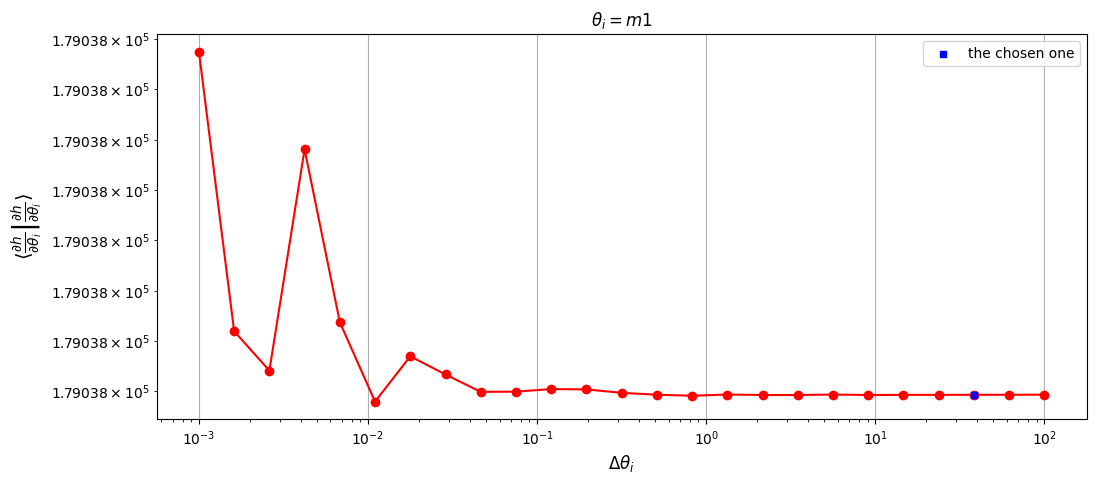

Gamma_ii for m2: 132041742203951.77
Gamma_ii for m2: 132041742201779.08
Gamma_ii for m2: 132041742196959.88
Gamma_ii for m2: 132041742194564.9
Gamma_ii for m2: 132041742184762.1
Gamma_ii for m2: 132041742204210.81
Gamma_ii for m2: 132041742202163.53
Gamma_ii for m2: 132041742197945.72
Gamma_ii for m2: 132041742197682.11
Gamma_ii for m2: 132041742288848.38
Gamma_ii for m2: 132041742205648.9
Gamma_ii for m2: 132041742397469.5
Gamma_ii for m2: 132041742728767.66
Gamma_ii for m2: 132041742103364.86
Gamma_ii for m2: 132041742420772.4
Gamma_ii for m2: 132041741543190.72
Gamma_ii for m2: 132041743321883.0
Gamma_ii for m2: 132041743827184.14
Gamma_ii for m2: 132041742790509.66
Gamma_ii for m2: 132041745909459.92
Gamma_ii for m2: 132041772835649.3
Gamma_ii for m2: 132041758864713.69
Gamma_ii for m2: 132041749698399.36
Gamma_ii for m2: 132041716233284.61
Gamma_ii for m2: 132041741377586.77
[np.float64(1.6454550385133634e-11), np.float64(3.6497573000903325e-11), np.float64(1.8137966904973036e-11)

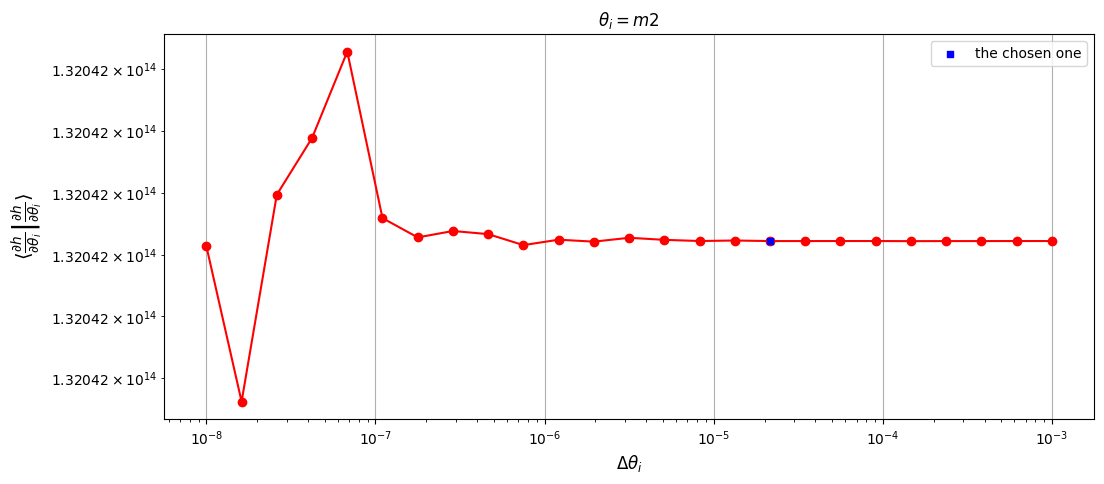

Gamma_ii for a: 8035304626791700.0
Gamma_ii for a: 8035303489929091.0
Gamma_ii for a: 8035303473657928.0
Gamma_ii for a: 8035304880663799.0
Gamma_ii for a: 8035292407605716.0
Gamma_ii for a: 8035309737584907.0
Gamma_ii for a: 8035320145526496.0
Gamma_ii for a: 8035318296485253.0
Gamma_ii for a: 8035306380691710.0
Gamma_ii for a: 8035375749034947.0
Gamma_ii for a: 8035311115332437.0
Gamma_ii for a: 8035328376965221.0
Gamma_ii for a: 8035573598987495.0
Gamma_ii for a: 8035431649997239.0
Gamma_ii for a: 8035886205927795.0
Gamma_ii for a: 8034902102094199.0
Gamma_ii for a: 8035157412330094.0
Gamma_ii for a: 8033880817268293.0
Gamma_ii for a: 8038941942731095.0
Gamma_ii for a: 8042616142897184.0
Gamma_ii for a: 8040783885841576.0
Gamma_ii for a: 8082994219160986.0
Gamma_ii for a: 8057476768950966.0
Gamma_ii for a: 8051728141256588.0
Gamma_ii for a: 8112788556611382.0
[np.float64(1.4148346859889825e-07), np.float64(2.0249593625606832e-09), np.float64(1.751029851257824e-07), np.float64(1.5522

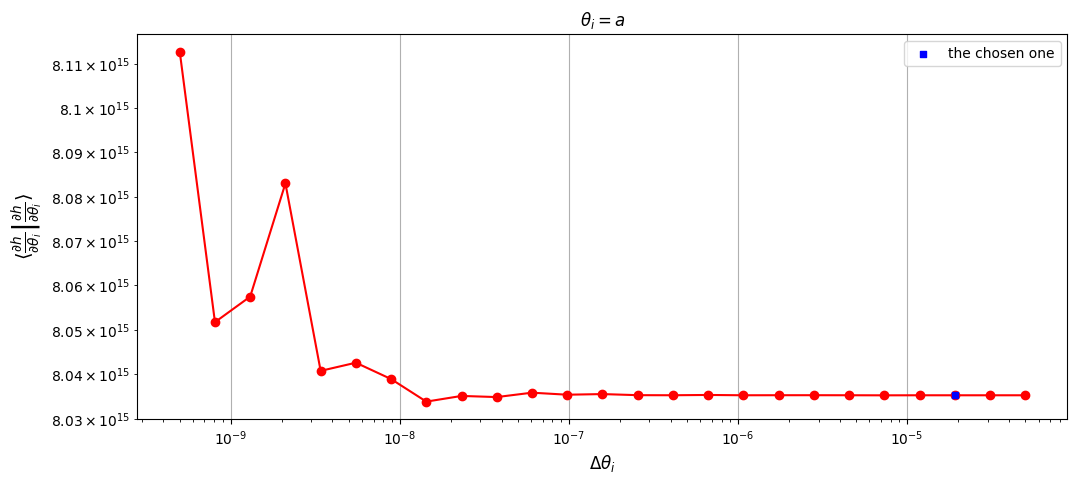

Gamma_ii for p0: 6112949919460070.0
Gamma_ii for p0: 6112950092982178.0
Gamma_ii for p0: 6112949925600160.0
Gamma_ii for p0: 6112949977412557.0
Gamma_ii for p0: 6112949695540928.0
Gamma_ii for p0: 6112950290976546.0
Gamma_ii for p0: 6112949401448129.0
Gamma_ii for p0: 6112950223279495.0
Gamma_ii for p0: 6112951351389631.0
Gamma_ii for p0: 6112954834170683.0
Gamma_ii for p0: 6112955768711625.0
Gamma_ii for p0: 6112946658609720.0
Gamma_ii for p0: 6112941665589389.0
Gamma_ii for p0: 6112932108390177.0
Gamma_ii for p0: 6112968225593426.0
Gamma_ii for p0: 6112916087184610.0
Gamma_ii for p0: 6112986546742108.0
Gamma_ii for p0: 6112697076247465.0
Gamma_ii for p0: 6112958022455905.0
Gamma_ii for p0: 6113159787242631.0
Gamma_ii for p0: 6113322373934419.0
Gamma_ii for p0: 6112312376963236.0
Gamma_ii for p0: 6111299970818661.0
Gamma_ii for p0: 6112964616001457.0
Gamma_ii for p0: 6116331572245028.0
[np.float64(2.838598473087614e-08), np.float64(2.7381545740956924e-08), np.float64(8.475841809837737

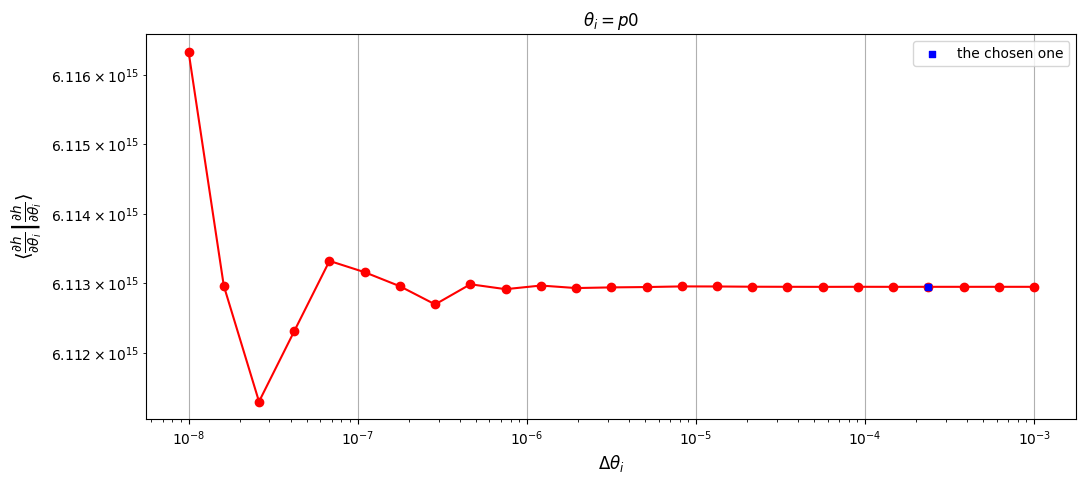

Gamma_ii for e0: 1.3424008007829596e+16
Gamma_ii for e0: 1.3424008556413298e+16
Gamma_ii for e0: 1.3424016576284176e+16
Gamma_ii for e0: 1.3424005671556422e+16
Gamma_ii for e0: 1.3424015807342172e+16
Gamma_ii for e0: 1.3424000209612838e+16
Gamma_ii for e0: 1.3424034353551114e+16
Gamma_ii for e0: 1.3423969791499214e+16
Gamma_ii for e0: 1.3424027927162136e+16
Gamma_ii for e0: 1.3423638815927978e+16
Gamma_ii for e0: 1.3423506955269574e+16
Gamma_ii for e0: 1.3423619698704712e+16
Gamma_ii for e0: 1.3424950712912152e+16
Gamma_ii for e0: 1.3423853079697322e+16
Gamma_ii for e0: 1.3428399267260444e+16
Gamma_ii for e0: 1.3427213591238782e+16
Gamma_ii for e0: 1.3419825457770246e+16
Gamma_ii for e0: 1.3425615160501788e+16
Gamma_ii for e0: 1.3427688031700856e+16
Gamma_ii for e0: 1.3462899190127846e+16
Gamma_ii for e0: 1.342293715043078e+16
Gamma_ii for e0: 1.3498698628277194e+16
Gamma_ii for e0: 1.3415828715848002e+16
Gamma_ii for e0: 1.3506617562594868e+16
Gamma_ii for e0: 1.3518723585218522e+16
[

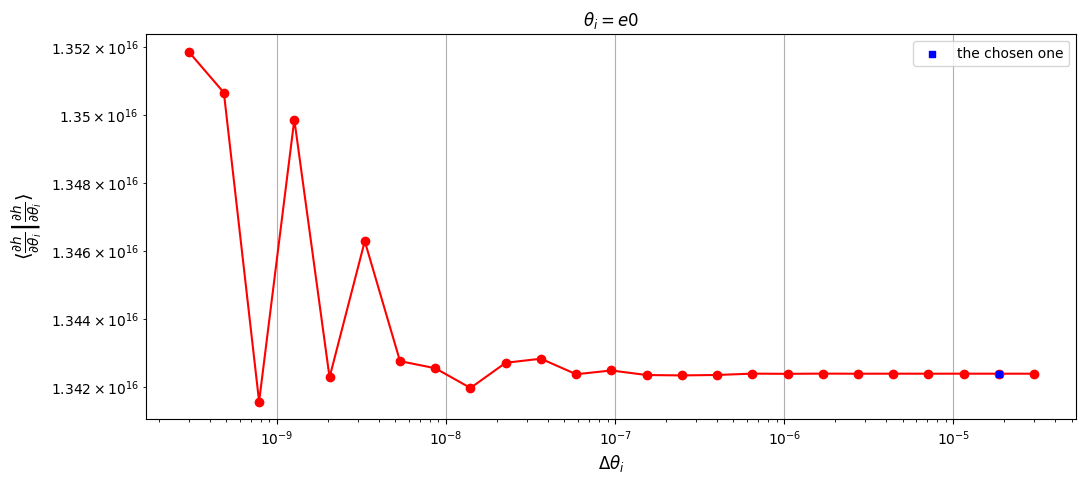

Gamma_ii for qS: 1077386.8430154594
Gamma_ii for qS: 1083253.4310969114
Gamma_ii for qS: 1083548.3825571726
Gamma_ii for qS: 1083635.2631837847
Gamma_ii for qS: 1083171.4721294306
Gamma_ii for qS: 1083223.083905788
Gamma_ii for qS: 1083362.486383766
Gamma_ii for qS: 1083673.9343309875
Gamma_ii for qS: 1083579.0037197617
Gamma_ii for qS: 1084581.1987047084
Gamma_ii for qS: 1086577.9647065091
Gamma_ii for qS: 1092805.31750241
Gamma_ii for qS: 1085319.858851268
Gamma_ii for qS: 1083185.7643994072
Gamma_ii for qS: 1083138.930642657
Gamma_ii for qS: 1083151.9726378014
Gamma_ii for qS: 1083113.4950040127
Gamma_ii for qS: 1083142.013227679
Gamma_ii for qS: 1083638.2974666422
Gamma_ii for qS: 1084911.778569318
Gamma_ii for qS: 1083888.6393910174
Gamma_ii for qS: 1084505.482673988
Gamma_ii for qS: 1083733.1764659947
Gamma_ii for qS: 1083513.3089105403
Gamma_ii for qS: 1083798.28566943
[np.float64(0.005415711515920617), np.float64(0.0002722088510390701), np.float64(8.017515631306573e-05), np.flo

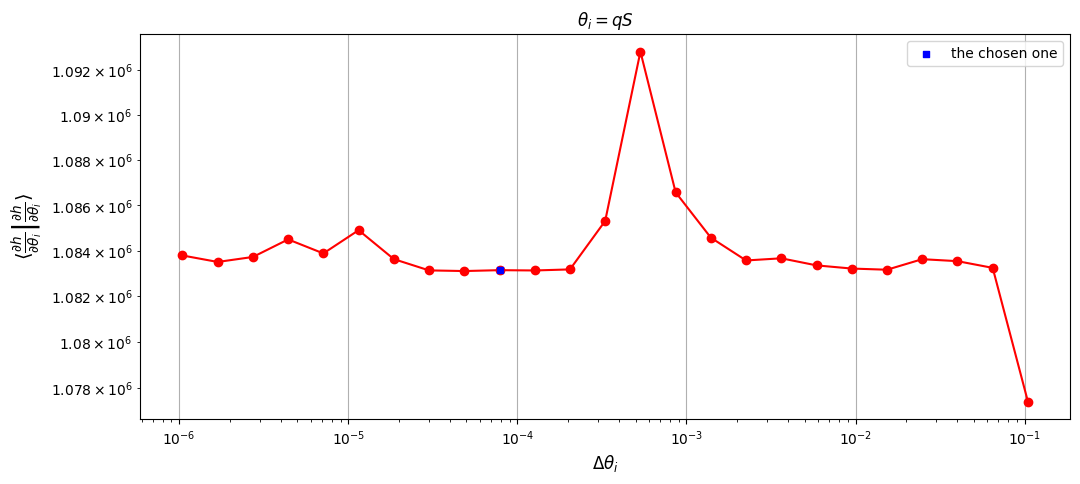

Gamma_ii for phiS: 3421255.719242125
Gamma_ii for phiS: 3476167.781832386
Gamma_ii for phiS: 3477325.7379259244
Gamma_ii for phiS: 3477679.7524402714
Gamma_ii for phiS: 3477712.5148226065
Gamma_ii for phiS: 3477629.123873006
Gamma_ii for phiS: 3477740.0028365753
Gamma_ii for phiS: 3478026.3214104837
Gamma_ii for phiS: 3478703.8808692223
Gamma_ii for phiS: 3477683.1142486115
Gamma_ii for phiS: 3477576.3532486456
Gamma_ii for phiS: 3477536.9415817433
Gamma_ii for phiS: 3477571.359098611
Gamma_ii for phiS: 3477552.0456939535
Gamma_ii for phiS: 3477529.6809388665
Gamma_ii for phiS: 3477527.789412262
Gamma_ii for phiS: 3477625.126259562
Gamma_ii for phiS: 3477878.807643569
Gamma_ii for phiS: 3478149.270514023
Gamma_ii for phiS: 3478175.022639775
Gamma_ii for phiS: 3482495.940385695
Gamma_ii for phiS: 3480638.5133562875
Gamma_ii for phiS: 3480453.9200677467
Gamma_ii for phiS: 3478584.269147536
Gamma_ii for phiS: 3479181.390757752
[np.float64(0.015796723874276084), np.float64(0.00033300190456

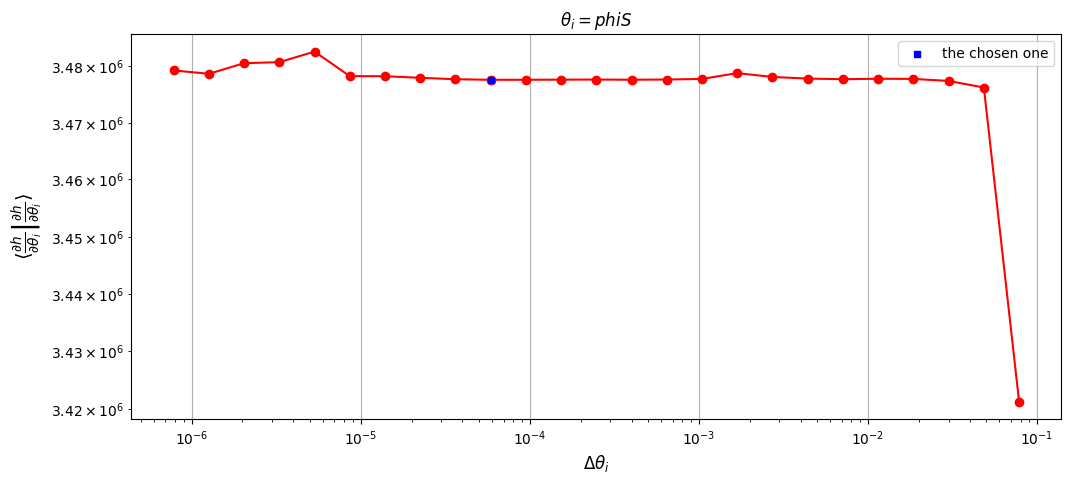

stable deltas: {'m1': 38.31325231332065, 'm2': 2.154463457367635e-05, 'a': 1.9157927272801146e-05, 'p0': 0.0002364358505421075, 'e0': 1.8568471699822827e-05, 'qS': 7.838693595685314e-05, 'phiS': 5.878003884875617e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 74.35789632797241 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.2492482662200928 seconds
[FISHER] array([[ 1.79037975e+05, -4.74129863e+09,  3.58672108e+10,
         3.30049175e+10,  4.66751430e+10,  2.34080602e+05,
        -6.32487236e+05, -1.46214270e+05, -4.02039622e+04],
       [-4.74129863e+09,  1.32041742e+14, -1.01960453e+15,
        -8.86932990e+14, -1.14673325e+15, -6.10877121e+09,
         1.77602278e+10,  3.45399950e+09,  7.34248630e+08],
       [ 3.58672108e+10, -1.01960453e+15,  8.03530347e+15,
         6.76784041e+15,  8.41338576e+15,  4.70215496e+10,
        -1.37833708e+11, -2.57209876e+10, -3.71

In [4]:
# ---------------------------------------------------------------------------
# Noise PSD and SNR check
# ---------------------------------------------------------------------------
PSD_funcs = xp.array(generate_PSD(
    waveform=waveform_true,
    dt=dt,
    noise_PSD=get_sensitivity,
    channels=channels,
    noise_kwargs=noise_kwargs,
    use_gpu=use_gpu,
))
print("shape check - waveform_true:", xp.shape(waveform_true),
      "PSD_funcs:", xp.shape(PSD_funcs))

freq_mask = make_freq_mask(waveform_true.shape[-1], dt, F_MIN)
snr = np.sqrt(_to_float(inner_product(
    waveform_true, waveform_true, PSD_funcs, dt, freq_mask=freq_mask, use_gpu=use_gpu)))
print(f"[TRUE] SNR: {snr:.6f}")
for i in range(PSD_funcs.shape[0]):
    snr_i = np.sqrt(_to_float(inner_product(
        waveform_true[i:i + 1], waveform_true[i:i + 1],
        PSD_funcs[i:i + 1], dt, freq_mask=freq_mask, use_gpu=use_gpu)))
    print(f"[TRUE] SNR - channel {i}: {snr_i:.6f}")

# ---------------------------------------------------------------------------
# Approximate template: Fisher matrix and partial derivatives (StableEMRIFisher)
# ---------------------------------------------------------------------------
sef = StableEMRIFisher(
    waveform_class=SuperKludgeWaveform,
    waveform_class_kwargs=dict(sum_kwargs=dict(pad_output=True, odd_len=True)),
    waveform_generator=GenerateEMRIWaveform,
    waveform_generator_kwargs=dict(return_list=False),
    ResponseWrapper=ResponseWrapper,
    ResponseWrapper_kwargs=build_response_kwargs(),
    stats_for_nerds=True,
    use_gpu=use_gpu,
    deriv_type="stable",
    noise_model=get_sensitivity,
    noise_kwargs=noise_kwargs,
    channels=channels,
    T=T,
    dt=dt,
    stability_plot=False,
    der_order=6,
    Ndelta=12,
    plunge_check=True,
    return_derivatives=True,
)

emri_kwargs = {"T": T, "dt": dt}

# The approximate template is evaluated at the maximum-likelihood point.
# (cfg validates cfg.analysis against its supported set on construction.)
fisher_params = mlp_points[0:14]
evolve_1PA = cfg.analysis == "1PA"
deviation_included = "dev" in cfg.analysis  # 0PA_dev_simple, 0PA_dev_PN

additional_kwargs = {
    "chi2": chi2,
    "evolve_1PA": evolve_1PA,
    "evolve_primary": False,
    "evolve_2PA": False,
    "deviation_included": deviation_included,
    "dev_1": dev_1,
    "dev_2": dev_2,
}
pars_list_com = list(fisher_params) + [
    chi2, evolve_1PA, False, False, deviation_included, dev_1, dev_2,
]

SNR = sef.SNRcalc_SEF(*pars_list_com, **emri_kwargs, use_gpu=use_gpu)
print("SNR: ", SNR)

param_names_14 = ["m1", "m2", "a", "p0", "e0", "xI0", "dist", "qS", "phiS",
                  "qK", "phiK", "Phi_phi0", "Phi_theta0", "Phi_r0"]
param_dict = dict(zip(param_names_14, fisher_params))

Fisher = sef(
    wave_params=param_dict,
    param_names=params_to_infer,
    add_param_args=additional_kwargs,
    live_dangerously=False,
    stability_plot=True,
    der_order=8,
    Ndelta=25,
)

# SEF returns (derivatives, Fisher_matrix) when return_derivatives=True.
# The Fisher matrix is already a host NumPy float64 array; keep it on the CPU.
fisher_matrix = np.asarray(Fisher[-1], dtype=float)
print(f"[FISHER] {fisher_matrix!r}")
print(f"[FISHER_IS_PD] {_is_pos_def(fisher_matrix)}")
fisher_inv = fishinv(param_dict["m1"], fisher_matrix, index_of_M=0)
print(f"[FISHER_INV] {fisher_inv!r}")
print(f"[FISHER_INV_IS_PD] {_is_pos_def(fisher_inv)}")
fisher_std = np.sqrt(np.diag(fisher_inv))
print(f"[FISHER_STD] {fisher_std!r}")

# ---------------------------------------------------------------------------
# Cutler-Vallisneri bias
# ---------------------------------------------------------------------------
waveform_approx = xp.array(sef.waveform)   # 0PA template (GPU), (n_channels, N)
partials_approx = xp.array(Fisher[0])      # derivatives (GPU), (n_params, n_channels, N)
print("shape of waveform_approx:", waveform_approx.shape)

# True values of the inferred parameters, ordered to match the Fisher matrix.
truth_by_name = dict(zip(param_names_14, cfg.signal_row[:14]))
truth_by_name.update(dev_1=dev_1, dev_2=dev_2)
true_inferred = np.array([truth_by_name[name] for name in params_to_infer])


In [5]:
Fisher[0]

[array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 7889537)),
 array([[0., 0., 0., ..., 0

In [6]:
# CV expands about the point where Gamma/derivatives were evaluated: the MLP.
mlp_by_name = dict(param_dict)                          # 14 EMRI params at the MLP
mlp_by_name.update(dev_1=mlp_points[17], dev_2=mlp_points[18])
base_inferred = np.array([mlp_by_name[name] for name in params_to_infer])

best_fit, bias = cutler_vallisneri_bias(
    waveform_true=waveform_true,
    waveform_approx=waveform_approx,
    partials_approx=partials_approx,
    fisher_approx=fisher_matrix,
    base_params=base_inferred,          # theta_BF = MLP + delta
    psd=PSD_funcs,
    dt=dt,
    param_names=params_to_infer,
    use_gpu=use_gpu,
    fmin=1e-5,
)

# best_fit = MLP + delta is the predicted 0PA best-fit; compare it to the truth.
residual = best_fit - true_inferred
print(f"[CV] bias vector (delta): {bias!r}")
print("[CV] param        MLP            delta        best_fit        true"
      "        best_fit-true   (in sigma)")
for name, mlp_v, d, bf, tr, res, sig in zip(
        params_to_infer, base_inferred, bias, best_fit, true_inferred,
        residual, fisher_std):
    print(f"[CV] {name:10s} {mlp_v: .6e} {d: .3e} {bf: .6e} {tr: .6e} "
          f"{res: .3e} {res / sig: .2f}")


[CV] bias in m1: 1.143117e-01
[CV] bias in m2: 3.404762e-07
[CV] bias in a: 1.077869e-07
[CV] bias in p0: -6.399262e-07
[CV] bias in e0: -3.702198e-08
[CV] bias in qS: 2.581679e-05
[CV] bias in phiS: 2.041254e-05
[CV] bias in Phi_phi0: -1.004143e-03
[CV] bias in Phi_r0: 2.330631e-04
[CV] bias vector (delta): array([ 1.14311675e-01,  3.40476240e-07,  1.07786870e-07, -6.39926188e-07,
       -3.70219781e-08,  2.58167936e-05,  2.04125407e-05, -1.00414339e-03,
        2.33063065e-04])
[CV] param        MLP            delta        best_fit        true        best_fit-true   (in sigma)
[CV] m1          1.000036e+06  1.143e-01  1.000036e+06  1.000000e+06  3.623e+01  5.87
[CV] m2          1.000013e+01  3.405e-07  1.000013e+01  1.000000e+01  1.339e-04  6.78
[CV] a           5.000520e-01  1.078e-07  5.000521e-01  5.000000e-01  5.213e-05  8.15
[CV] p0          9.970417e+00 -6.399e-07  9.970417e+00  9.970668e+00 -2.517e-04 -7.05
[CV] e0          2.999919e-01 -3.702e-08  2.999918e-01  3.000000e-01 -

In [7]:
# ---------------------------------------------------------------------------
# Validation via overlap (match) and chi^2 of templates with the 1PA signal.
#
# CV predicts the 0PA best-fit theta_BF (biased away from truth). Two facts:
#   * 0PA(theta_BF) matches the 1PA signal well  -> the bias is what makes the
#     wrong (0PA) model fit; this is the "high overlap" CV relies on.
#   * 1PA(theta_BF) does NOT match the signal     -> theta_BF is biased, so the
#     CORRECT (1PA) model at those params does not reproduce the truth.
# The MLP is the 0PA maximum-likelihood point, so overlap(0PA-MLP) is the
# fitting factor (upper bound for any 0PA template).
# ---------------------------------------------------------------------------
overlap_freq_mask = make_freq_mask(waveform_true.shape[-1], dt, F_MIN)


def _ip(a, b):
    """Noise-weighted inner product <a|b> over channels (same mask as the bias)."""
    return _to_float(inner_product(a, b, PSD=PSD_funcs, dt=dt,
                                   freq_mask=overlap_freq_mask, use_gpu=use_gpu))


def normalized_overlap(a, b):
    """Match  <a|b> / sqrt(<a|a><b|b>)  summed over channels."""
    return _ip(a, b) / np.sqrt(_ip(a, a) * _ip(b, b))


def residual_chi2(h):
    """chi^2 = <r|r> with residual r = h_1PA(signal) - h (noise-weighted)."""
    r = waveform_true - h
    return _ip(r, r)


mlp14 = dict(zip(param_names_14, fisher_params))   # 14 EMRI params at the MLP


def make_waveform(inferred_values, evolve_1pa):
    """Response waveform of the 0PA (evolve_1pa=False) or 1PA (evolve_1pa=True)
    model, with the inferred parameters set to ``inferred_values`` ({name: value})
    and every non-inferred parameter held at its MLP value."""
    p14 = {n: inferred_values.get(n, mlp14[n]) for n in param_names_14}
    dv1 = inferred_values.get("dev_1", mlp_points[17])
    dv2 = inferred_values.get("dev_2", mlp_points[18])
    wave_params = [p14[n] for n in param_names_14] + [
        chi2, evolve_1pa, False, False, deviation_included, dv1, dv2,
    ]
    return xp.array(waveform_response(*wave_params))[:nchannels, :]


true_vals = dict(zip(params_to_infer, true_inferred))
mlp_vals = dict(zip(params_to_infer, base_inferred))
cv_vals = dict(zip(params_to_infer, best_fit))

# --- 0PA (approximate model) templates: overlap with the 1PA signal ---
waveform_0pa_true = make_waveform(true_vals, evolve_1pa=False)
waveform_0pa_mlp = make_waveform(mlp_vals, evolve_1pa=False)
waveform_0pa_cv = make_waveform(cv_vals, evolve_1pa=False)

overlap_0pa_true = normalized_overlap(waveform_true, waveform_0pa_true)
overlap_0pa_mlp = normalized_overlap(waveform_true, waveform_0pa_mlp)   # fitting factor
overlap_0pa_cv = normalized_overlap(waveform_true, waveform_0pa_cv)

print("--- 0PA (approximate model) vs 1PA signal ---")
print(f"[OVERLAP] 0PA(true inj)     : {overlap_0pa_true:.6f}  (mismatch {1 - overlap_0pa_true:.3e})")
print(f"[OVERLAP] 0PA(MLP)          : {overlap_0pa_mlp:.6f}  (mismatch {1 - overlap_0pa_mlp:.3e})  <- fitting factor")
print(f"[OVERLAP] 0PA(CV-corrected) : {overlap_0pa_cv:.6f}  (mismatch {1 - overlap_0pa_cv:.3e})  <- CV relation: HIGH")

# --- 1PA (correct model) templates at the same parameter points ---
waveform_1pa_true = make_waveform(true_vals, evolve_1pa=True)   # sanity: ~ the signal
waveform_1pa_cv = make_waveform(cv_vals, evolve_1pa=True)       # 1PA at the biased params

overlap_1pa_true = normalized_overlap(waveform_true, waveform_1pa_true)
overlap_1pa_cv = normalized_overlap(waveform_true, waveform_1pa_cv)

print("\n--- 1PA (correct model) vs 1PA signal ---")
print(f"[OVERLAP] 1PA(true inj)     : {overlap_1pa_true:.6f}   <- sanity, should be ~1")
print(f"[OVERLAP] 1PA(CV-corrected) : {overlap_1pa_cv:.6f}   <- 1PA at biased params: LOW if the bias is many-sigma")

# --- chi^2 = <r|r> : noise-weighted squared residual (what the fit minimises) ---
snr2 = _ip(waveform_true, waveform_true)             # <s|s> = 1PA SNR^2
print("\n--- chi^2 = <r|r>, r = signal - template ---")
print(f"[CHI2] <s|s> 1PA (SNR^2)        : {snr2:.6e}   (SNR = {np.sqrt(snr2):.3f})")
print(f"[CHI2] 0PA(true inj)            : {residual_chi2(waveform_0pa_true):.6e}")
print(f"[CHI2] 0PA(MLP)                 : {residual_chi2(waveform_0pa_mlp):.6e}")
print(f"[CHI2] 0PA(CV-corrected)        : {residual_chi2(waveform_0pa_cv):.6e}")
print(f"[CHI2] 1PA(CV-corrected)        : {residual_chi2(waveform_1pa_cv):.6e}   <- correct model, biased params")


--- 0PA (approximate model) vs 1PA signal ---
[OVERLAP] 0PA(true inj)     : -0.042224  (mismatch 1.042e+00)
[OVERLAP] 0PA(MLP)          : 0.999757  (mismatch 2.429e-04)  <- fitting factor
[OVERLAP] 0PA(CV-corrected) : 0.999757  (mismatch 2.429e-04)  <- CV relation: HIGH

--- 1PA (correct model) vs 1PA signal ---
[OVERLAP] 1PA(true inj)     : 1.000000   <- sanity, should be ~1
[OVERLAP] 1PA(CV-corrected) : -0.044576   <- 1PA at biased params: LOW if the bias is many-sigma

--- chi^2 = <r|r>, r = signal - template ---
[CHI2] <s|s> 1PA (SNR^2)        : 3.832568e+04   (SNR = 195.769)
[CHI2] 0PA(true inj)            : 7.988441e+04
[CHI2] 0PA(MLP)                 : 1.867583e+01
[CHI2] 0PA(CV-corrected)        : 1.867173e+01
[CHI2] 1PA(CV-corrected)        : 8.014809e+04   <- correct model, biased params


In [8]:
# ---------------------------------------------------------------------------
# Iterated CV (Gauss-Newton): shift the base point to (base + delta), recompute
# the 0PA Fisher / derivatives / template THERE, and re-apply CV. This drives
# delta -> 0 and converges to the true 0PA best-fit; the overlap should climb
# and plateau at the fitting factor while chi2 = <r|r> drops to its minimum.
#
# NOTE: each iteration re-runs SEF (derivatives + Fisher) at the new point.
# The expensive delta-stability search is reused from the first Fisher run,
# so each step is one derivative+Fisher evaluation (still not free on the GPU).
# ---------------------------------------------------------------------------
stable_deltas = sef.deltas   # stable step sizes found during the first Fisher run


def run_sef_at(inferred_values):
    """0PA Fisher matrix, derivatives, and template at the given inferred point
    (non-inferred params held at their MLP values)."""
    p14 = {n: inferred_values.get(n, mlp14[n]) for n in param_names_14}
    akw = dict(additional_kwargs)
    for d in ("dev_1", "dev_2"):
        if d in inferred_values:
            akw[d] = inferred_values[d]
    F = sef(
        wave_params={n: p14[n] for n in param_names_14},
        param_names=params_to_infer,
        add_param_args=akw,
        deltas=stable_deltas,      # reuse stable steps -> skip the stability search
        live_dangerously=False,
        stability_plot=False,
        der_order=8,
    )
    return np.asarray(F[-1], dtype=float), xp.array(F[0]), xp.array(sef.waveform)


current = np.array(base_inferred, dtype=float)   # start from the supplied MLP
print(f"{'iter':>4}  {'overlap(0PA,1PA)':>18}  {'chi2=<r|r>':>14}  {'max|delta/sigma|':>16}")
for it in range(6):
    fmat_i, parts_i, wf_i = run_sef_at(dict(zip(params_to_infer, current)))
    sigma_i = np.sqrt(np.abs(np.diag(fishinv(current[0], fmat_i, index_of_M=0))))
    ov_i = normalized_overlap(waveform_true, wf_i)
    chi2_i = residual_chi2(wf_i)
    _, delta_i = cutler_vallisneri_bias(
        waveform_true=waveform_true, waveform_approx=wf_i,
        partials_approx=parts_i, fisher_approx=fmat_i,
        base_params=current, psd=PSD_funcs, dt=dt,
        param_names=None, fmin=F_MIN, use_gpu=use_gpu,
    )
    step = float(np.max(np.abs(delta_i / sigma_i)))
    print(f"{it:>4}  {ov_i:>18.8f}  {chi2_i:>14.6e}  {step:>16.3e}")
    current = current + delta_i
    if step < 1e-2:
        print("converged: max|delta/sigma| < 1e-2")
        break

# Converged 0PA best-fit vs the truth -> this is the actual systematic bias.
fmat_f, _, wf_f = run_sef_at(dict(zip(params_to_infer, current)))
sigma_f = np.sqrt(np.abs(np.diag(fishinv(current[0], fmat_f, index_of_M=0))))
print(f"\nfinal overlap 0PA(converged) vs 1PA : {normalized_overlap(waveform_true, wf_f):.8f}")
print(f"final chi2 = <r|r>                   : {residual_chi2(wf_f):.6e}   (SNR^2 = {snr2:.6e})")
print(f"{'param':10s} {'converged 0PA fit':>20} {'true inj':>16} {'(fit-true)/sigma':>18}")
for name, val, tr, sg in zip(params_to_infer, current, true_inferred, sigma_f):
    print(f"{name:10s} {val:>20.8e} {tr:>16.8e} {(val - tr) / sg:>18.3f}")


iter    overlap(0PA,1PA)      chi2=<r|r>  max|delta/sigma|
Body is not plunging, Fisher should be stable.
waveform shape: (3, 7889537)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000036.1198187952), np.float64(10.000133526144388), np.float64(0.500052021086232), np.float64(9.970417145876961), np.float64(0.2999918756916836), 1.0, 1, np.float64(1.0453065910007755), np.float64(0.7838444158820905), 0.628318531, 0.523598776, np.float64(0.1142105583644897), 0.2, np.float64(0.25394659948792797), 0.95, False, False, False, False, 0.0, 0.0)
Waveform Generated. SNR: 195.96123098635348
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.2266159057617188 seconds
   0          0.99975706    1.867583e+01         5.893e-02
Body is not plunging, Fisher should be stable.
waveform shape: (3, 7889537)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000036.2341304698), np.float64(10.000133866620628), np.float6

In [9]:
current

array([1.00003623e+06, 1.00001339e+01, 5.00052129e-01, 9.97041651e+00,
       2.99991839e-01, 1.04533235e+00, 7.83864901e-01, 1.13205146e-01,
       2.54180379e-01])

What the code computes
Ingredients (cutler_vallisneri_bias):

code	symbol	meaning
waveform_true	$s = h_{\rm 1PA}(\theta_{\rm tr})$	injected signal (1PA at truth)
waveform_approx	$h_{\rm AP}(\theta_0)=h_{\rm 0PA}(\theta_0)$	recovery template at the base point
partials_approx[j]	$\partial_j h_{\rm AP}(\theta_0)$	0PA derivative w.r.t. inferred param $j$
fisher_approx	$\Gamma_{ij}$	Fisher of the 0PA model
base_params	$\theta_0$	MLP (or current iterate)
with the noise-weighted, band-limited inner product and Fisher

$$\langle a\mid b\rangle ;=; 4,\mathrm{Re}!\sum_{\rm chans}\int_{f_{\min}}^{\infty}\frac{\tilde a^*(f),\tilde b(f)}{S_n(f)},df,\qquad \Gamma_{ij}(\theta)=\big\langle\partial_i h_{\rm AP}(\theta),\big|,\partial_j h_{\rm AP}(\theta)\big\rangle .$$

One call does:

$$\boxed{;\Delta\theta^{i}=(\Gamma^{-1})^{ij},\big\langle,\partial_j h_{\rm AP}(\theta_0);\big|;s-h_{\rm AP}(\theta_0),\big\rangle,\qquad \theta_{\rm new}=\theta_0+\Delta\theta;}$$

The iteration cell just repeats it, moving the base point each time:

$$\theta_{k+1}=\theta_k+\Gamma(\theta_k)^{-1}\big\langle,\partial h_{\rm AP}(\theta_k);\big|;s-h_{\rm AP}(\theta_k),\big\rangle .$$

Technically this is CV bias — but…
The textbook Cutler–Vallisneri bias (CV 2007, Eq. 29) is the same formula evaluated once at the truth:

$$\Delta\theta^{i}{\rm CV}=\big(\Gamma^{-1}(\theta{\rm tr})\big)^{ij}\big\langle,\partial_j h_{\rm AP}(\theta_{\rm tr});\big|;h_{\rm TR}(\theta_{\rm tr})-h_{\rm AP}(\theta_{\rm tr}),\big\rangle,\qquad \theta_{\rm BF}\approx\theta_{\rm tr}+\Delta\theta_{\rm CV}.$$

It's a single, first-order prediction of the systematic offset, trusted only when $|\Delta\theta|\lesssim\sigma$. What our code does is the identical algebra but:

anchored at the MLP, not the truth, and
iterated.
That turns it into a Gauss–Newton solve of the nonlinear least-squares problem "maximize the 0PA↔1PA overlap." Its fixed point is the exact 0PA best-fit,

$$\big\langle,\partial h_{\rm AP}(\theta_{\rm BF});\big|;s-h_{\rm AP}(\theta_{\rm BF}),\big\rangle=0,$$

i.e. the 0PA maximum-likelihood point. So:

one step from truth → the CV bias (predict where the fit lands);
one step from the MLP → a refinement/consistency check of the MLP ($\Delta\theta\to0$ iff the MLP is already the MLE);
iterating → finding the MLE, not predicting a bias.
The crucial caveat — and why the previous run drifted to the injection — is the approximation hiding in $\Gamma$. The true Hessian of $\tfrac12\chi^2$ is

$$H_{ij}=\underbrace{\langle\partial_i h\mid\partial_j h\rangle}{\Gamma{ij}}-\underbrace{\langle\partial_i\partial_j h\mid s-h\rangle}_{\text{dropped}}.$$

Gauss–Newton/CV keeps only $\Gamma$ and drops the second term, which is fine only when the residual $s-h$ is small. At overlap(0PA@truth)=0.11 the residual is huge, so far from the optimum $\Gamma$ is a poor Hessian → undamped steps overshoot. That's a genuine "using it slightly out of regime," even though the formula is exactly CV.

The multi-case 0PA sweep
I have all three cases (idx 0, 9, 13) — signal params + the 0PA x_bf MLPs. To "see if the overlap can be improved" for each, the clean thing is a loop that, per case: builds $s=h_{\rm 1PA}$, the PSD, then runs the iteration above from that case's x_bf, reporting overlap and χ² before vs. after. That's three full GPU Fisher runs and needs restructuring the notebook (it's currently hard-wired to a single cfg).

Want me to add a sweep cell that loops over these three 0PA points (with a damped/line-searched step so it can't walk off to the injection), printing overlap_MLP → overlap_CV and Δθ/σ per case? Given the last result, I'd strongly recommend the damping — otherwise "improved?" is unanswerable when it diverges.

$$\Delta\theta = \Gamma(\theta_{\rm true})^{-1}\langle\partial h_{\rm 0PA}(\theta_{\rm true})\mid h_{\rm 1PA}(\theta_{\rm true})-h_{\rm 0PA}(\theta_{\rm true})\rangle,\qquad \theta_{\rm BF}\approx\theta_{\rm true}+\Delta\theta.$$